---

# 🟨 Naive Bayes Sınıflandırma — Ön Bilgilendirme

---

## 1️⃣ **Bayes Teoremi'nin Sezgisel Anlaşılması**

(197. video: *Understanding Bayes' Theorem Intuitively*)

### 📌 Bayes Teoremi Nedir?

Bayes Teoremi, yeni bir bilgi öğrendiğimizde bir olayın olasılığını **güncellemeye** yarayan olasılık kuralıdır.

**Formül:**

```
P(A|B) = [ P(B|A) * P(A) ] / P(B)
```

### 🔍 Ne demek?

> ❓“Eğer B olduysa, A’nın olma olasılığı nedir?”
> Örneğin: “Test pozitif çıktıysa gerçekten hasta olma ihtimali nedir?”

Bu, **öncül bilgi (prior)** ve **güncellenmiş bilgi (posterior)** kavramını getirir.

---

## 2️⃣ **Naive Bayes Algoritması Mantığı**

(198. video: *Understanding Naive Bayes Algorithm*)

### 📌 Naive Bayes Nedir?

Naive Bayes, Bayes teoremini baz alarak **veri noktalarının olasılıklarını hesaplayarak sınıflandırma** yapan bir algoritmadır.

> Yeni bir örnek geldiğinde:
> "Bu örneğin A sınıfına mı yoksa B sınıfına mı ait olma olasılığı daha yüksek?"

---

## 3️⃣ **Adım Adım Olasılık Hesabı**

(199. video: *Bayes Theorem in Machine Learning: Step-by-Step*)

### 📌 Nasıl hesaplanır?

Diyelim ki iki sınıf var: `Sınıf1`, `Sınıf2`. Yeni veri şu şekilde:

* Özellik1: Erkek
* Özellik2: 30 yaşında
* Özellik3: Satın aldı mı?

**Naive Bayes şöyle der:**

> Her sınıf için şu olasılığı hesapla:
> `P(Sınıf | Özellik1, Özellik2, Özellik3)`

Ve en yüksek olanı seç:

```python
Tahmin = argmax [P(Sınıf) * P(Özellik1|Sınıf) * P(Özellik2|Sınıf) * ...]
```

---

## 4️⃣ **Neden “Naive (Saf)” Deniyor?**

(200. video)

Çünkü algoritma **özelliklerin birbirinden bağımsız** olduğunu varsayar:

> ❗ Yani "yaş ile cinsiyet bağımsızdır" gibi düşünür.

Bu gerçek hayatta çoğu zaman **doğru değildir**, ama yine de model genelde **başarılı sonuçlar** verir.

---

## 5️⃣–7️⃣ **Python ile Uygulamalı Naive Bayes**

(201–203. videolar)

### 📦 Ne yapacaksın?

* **Sosyal ağ reklamları verisini** kullanarak sınıflandırma yapacaksın
* `NaiveBayesClassifier` ile modeli eğiteceksin
* Modeli test setinde deneyecek ve şu metrikleri inceleyeceksin:

  * Confusion Matrix
  * Accuracy
  * Tahminlerin görselleştirilmesi (decision boundary)

---

## ✅ Avantajları:

| Güçlü Yönler                   | Açıklama                                          |
| ------------------------------ | ------------------------------------------------- |
| 🔹 Hızlı                       | Eğitim ve tahmin çok hızlı                        |
| 🔹 Küçük veri setinde bile iyi | Az sayıda veriyle çalışabilir                     |
| 🔹 Metin verilerinde çok iyi   | Spam tespiti, duygu analizi gibi alanlarda etkili |
| 🔹 Eksik verilere toleranslı   | Eksik/bozuk veriyle bile çalışabilir              |

---

## ⚠️ Zayıf Yönleri:

| Zayıf Yön            | Açıklama                                                       |
| -------------------- | -------------------------------------------------------------- |
| Özellik bağımsızlığı | Özelliklerin birbirine bağlı olması modelin gücünü azaltabilir |
| Karmaşık ilişkiler   | Çok boyutlu, etkileşimli verilerde zayıf kalabilir             |

---

## 💻 Python'da Örnek Kullanım:

```python
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

> Genelde `GaussianNB` kullanılır çünkü sayısal özelliklerde (yaş, gelir vs.) **normal dağılım** varsayımı yapılır.

---

## 🎓 Özetle:

* **Naive Bayes**, olasılık temelli ve basit bir sınıflandırma yöntemidir.
* Özelliklerin **bağımsız olduğunu varsayar** ama buna rağmen çok başarılı olabilir.
* **Hızlıdır, yorumlanabilir, metin verilerinde çok güçlüdür.**
* Bayes Teoremi ile sınıfların olasılıkları hesaplanır ve **en yüksek olasılığa sahip sınıf seçilir.**

---

Video tamamlandıktan sonra birlikte gerçek veriyle adım adım uygulama, karar sınırı görselleştirmesi ve metrik analizi yapabiliriz.
Sonraki konu: **Decision Tree Classification** olacak. Hazır olduğunda yine buradayım!


## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Splitting the dataset into the Training set and Test set

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

## Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the Naive Bayes model on the Training set

In [5]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

## Predicting a new result

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


## Predicting the Test set results

In [7]:
y_pred = classifier.predict(X_test) # sağdaki gerçek değer soldaki modelin tahmini
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


## Making the Confusion Matrix

### 📌 Açıklamaları:

| Terim | Anlamı                                                                |
| ----- | --------------------------------------------------------------------- |
| TP    | Gerçek sınıf 1, model de 1 tahmin etti (doğru)                        |
| TN    | Gerçek sınıf 0, model de 0 tahmin etti (doğru)                        |
| FP    | Gerçek sınıf 0, ama model 1 dedi (yanlış pozitif — yanlış alarm)      |
| FN    | Gerçek sınıf 1, ama model 0 dedi (yanlış negatif — gözden kaçan vaka) |

---

### 💻 Python Örneği:

```python
from sklearn.metrics import confusion_matrix

y_true = [1, 0, 1, 0, 1, 0, 1]
y_pred = [1, 0, 1, 0, 0, 1, 1]

cm = confusion_matrix(y_true, y_pred)
print(cm)
```

Çıktı örneği:

```
[[2 1]
 [1 3]]
```

* TN = 2, FP = 1
* FN = 1, TP = 3

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[65  3]
 [ 7 25]]


0.9

## Visualising the Training set results

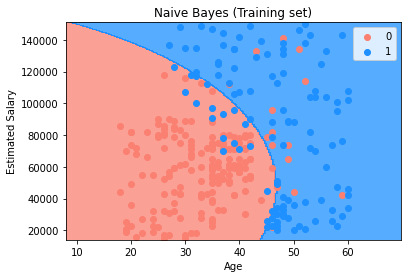

C:\Users\523579\AppData\Local\Temp\ipykernel_4688\4133870238.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


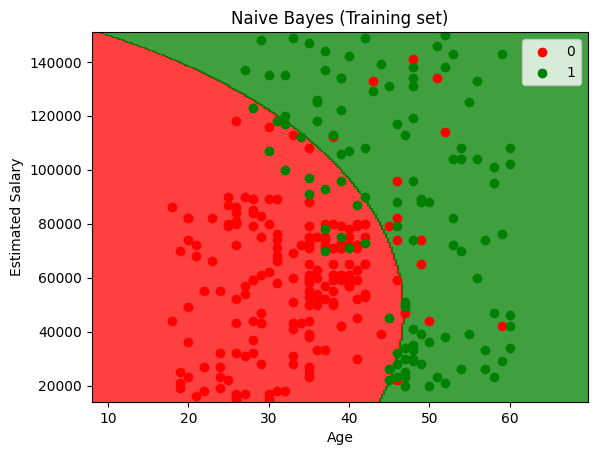

In [9]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results

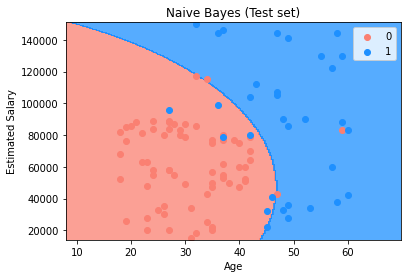

C:\Users\523579\AppData\Local\Temp\ipykernel_4688\299401745.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


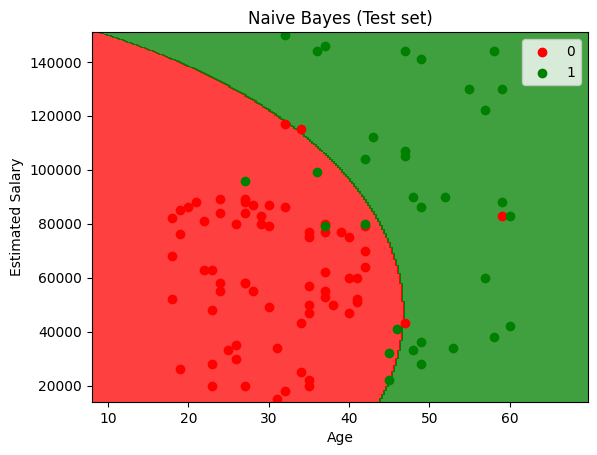

In [10]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()